In [3]:
import cv2
from glob import glob
from matplotlib import pyplot as plt
import numpy as np
import sys
import csv

### Experiment 1: Find a method to generate ground truth

In [4]:
# img_folders = ['bag1/','bag2/']
img_folders = ['bag3/','bag4/']

filenames = glob('orchard_images/'+img_folders[1]+'/depth*.png')

In [5]:
filenames

['orchard_images/bag4/depth1.png',
 'orchard_images/bag4/depth10.png',
 'orchard_images/bag4/depth100.png',
 'orchard_images/bag4/depth101.png',
 'orchard_images/bag4/depth102.png',
 'orchard_images/bag4/depth103.png',
 'orchard_images/bag4/depth104.png',
 'orchard_images/bag4/depth105.png',
 'orchard_images/bag4/depth106.png',
 'orchard_images/bag4/depth107.png',
 'orchard_images/bag4/depth108.png',
 'orchard_images/bag4/depth109.png',
 'orchard_images/bag4/depth11.png',
 'orchard_images/bag4/depth110.png',
 'orchard_images/bag4/depth111.png',
 'orchard_images/bag4/depth112.png',
 'orchard_images/bag4/depth113.png',
 'orchard_images/bag4/depth114.png',
 'orchard_images/bag4/depth116.png',
 'orchard_images/bag4/depth117.png',
 'orchard_images/bag4/depth118.png',
 'orchard_images/bag4/depth119.png',
 'orchard_images/bag4/depth12.png',
 'orchard_images/bag4/depth120.png',
 'orchard_images/bag4/depth121.png',
 'orchard_images/bag4/depth122.png',
 'orchard_images/bag4/depth123.png',
 'orch

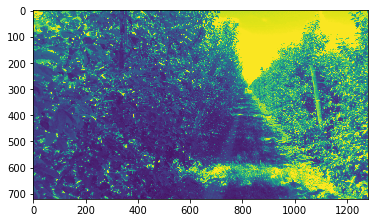

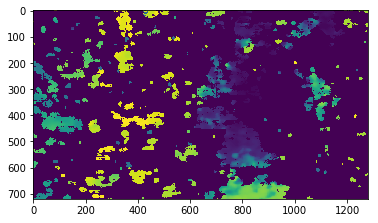

In [6]:
disp_to_img = cv2.imread('orchard_images/'+img_folders[0]+'/frame90.png',0)

plt.imshow(disp_to_img)

plt.show()

disp_to_img = cv2.imread('orchard_images/'+img_folders[0]+'/depth90.png',0)

plt.imshow(disp_to_img)

plt.show()

In [7]:
disp_to_img

array([[  0,   0,   0, ..., 194, 194, 194],
       [  0,   0,   0, ..., 194, 194, 194],
       [  0,   0,   0, ..., 194, 194,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [118, 117, 117, ...,   0,   0,   0]], dtype=uint8)

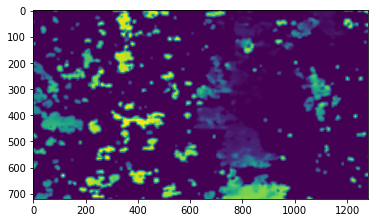

In [8]:
# Blur to fill up spaces in between the canopies
blur = cv2.blur(disp_to_img,(10,10))
plt.imshow(blur)

In [9]:
np.max(disp_to_img)

225

In [10]:
disp_to_img[disp_to_img==0] = np.max(disp_to_img)

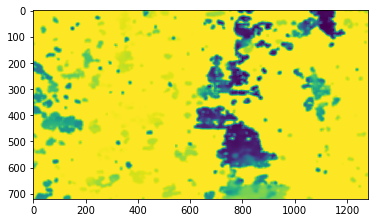

In [11]:
# Blur to fill up spaces in between the canopies
blur = cv2.blur(disp_to_img,(10,10))
plt.imshow(blur)

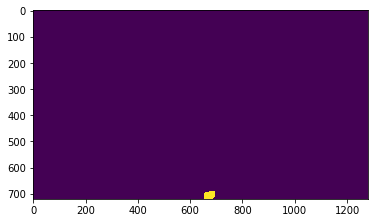

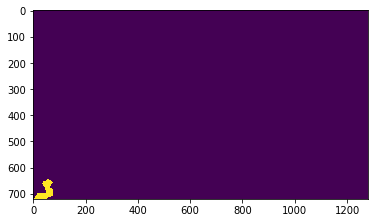

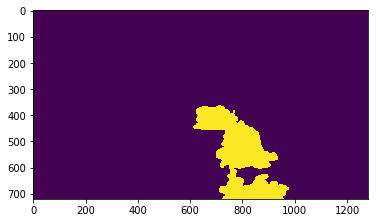

In [12]:
img = blur.flatten()
            
# Select the pixels with values lower than 20th percentile
mask = (img<np.percentile(img, 20)).astype(int)
mask = mask>0
mask = mask.reshape((disp_to_img.shape))
img_ = np.zeros((720, 1280, 3))
img_[:,:,2] = mask

# Find contours of the areas with higher depth
ret, thresh = cv2.threshold( (mask).astype('uint8'), 0, 1, 0)
contours, hierarchy = cv2.findContours( thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

mid = 600 # assumed mid point in the image
max_area = 1000 # The max area of the max depth portion in the image should be greater than this
max_cnt = 0 # This stores the contour of the max area

# This is like a double check
closeness_to_mid = 10000 # closeness to mid would help in choosing the max area closes to the mid

# i=1
# Iterate over all contours
for cnt in contours:
    area = cv2.contourArea(cnt)
    
    if area>max_area:
        mask = np.zeros((disp_to_img.shape))
        cv2.drawContours(mask,[cnt],0,1,-1)

        points = np.nonzero(mask)[1]
        pathMid = int(np.ceil(np.mean(points)))
        
        plt.imshow(mask)
        plt.show()
        
#         if abs(mid-pathMid)<closeness_to_mid:
#             print (area)
#             max_area = area
#             max_cnt = cnt.copy()
        max_area = area
        max_cnt = cnt.copy()

#             closeness_to_mid = abs(mid-pathMid)
#             plt.imshow(mask)
#             plt.show()

##             plt.imsave("depth_mask"+str(i)+".png", -mask, cmap='binary')
##             i+=1

### Experiment 2: Use above method to generate ground truth

In [13]:
kwargs = {'newline': ''}
mode = 'w'
if sys.version_info < (3, 0):
    kwargs.pop('newline', None)
    mode = 'wb'

with open('test.csv', mode, **kwargs) as fp:
# with open('monocularDepth_predictions/'+img_folders[0]+'/grounTruth.csv', mode, **kwargs) as fp:
# with open('monocularDepth_predictions/'+img_folders[1]+'/grounTruth.csv', mode, **kwargs) as fp:
    writer = csv.writer(fp, delimiter=',')
    
    for filename in filenames:
        disp_to_img = cv2.imread(filename, 0)
        blur = cv2.blur(disp_to_img,(10,10))
        img = blur.flatten()
        
        img[img==0] = np.max(img)

        mask = (img<np.percentile(img, 20)).astype(int)
        mask = mask>0
        mask = mask.reshape((disp_to_img.shape))
        img_ = np.zeros((720, 1280, 3))
        img_[:,:,2] = mask

        ret, thresh = cv2.threshold( (mask).astype('uint8'), 0, 1, 0)
        contours, hierarchy = cv2.findContours( thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        
        max_area = 1000
        max_cnt = 0
        closeness_to_mid = 10000
        for cnt in contours:
            area = cv2.contourArea(cnt)

            if area>max_area:
                mask = np.zeros((disp_to_img.shape))
                cv2.drawContours(mask,[cnt],0,1,-1)

                points = np.nonzero(mask)[1]
                pathMid = int(np.ceil(np.mean(points)))
                max_area = area
                max_cnt = cnt.copy()

#                 if abs(600-pathMid)<closeness_to_mid:
#                     max_area = area
#                     max_cnt = cnt.copy()

#                     closeness_to_mid = abs(600-pathMid)

        filename_ = filename.split('depth')
        
        # Save the ground truth
        writer.writerow([ filename_[1].split('.')[0], pathMid])

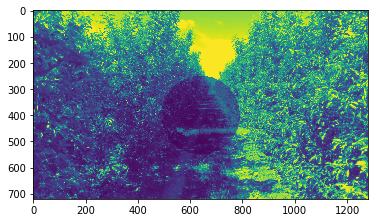

In [124]:
## Check where may the ground truth actually lies incase the calculation above is incorrect
alpha = 0.5
disp_to_img = cv2.imread('orchard_images/'+'bag3/frame9.png',0)
overlay = disp_to_img.copy()
output = disp_to_img.copy()
waypoint = cv2.circle(overlay, (int(640),400), 150, (0,255,0), -1)
waypoint = cv2.addWeighted(overlay, alpha, output, 1 - alpha, 0, output)
plt.imshow(output)